In [1]:
import yfinance as yf
import pandas as pd
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import time

In [81]:
!pip install xgboost -q

import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [84]:
# Style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")

# Load
df = pd.read_csv("processed_data.csv", parse_dates=["Date"])
df.sort_values(["Symbol", "Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(6185, 14)
Date           datetime64[ns]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
Symbol                 object
SMA_20                float64
SMA_50                float64
EMA_20                float64
EMA_50                float64
Rolling_Std           float64
BB_Upper              float64
BB_Lower              float64
dtype: object
Date             0
Close            0
High             0
Low              0
Open             0
Volume           0
Symbol           0
SMA_20          95
SMA_50         245
EMA_20           0
EMA_50           0
Rolling_Std     95
BB_Upper        95
BB_Lower        95
dtype: int64


,Date,Close,High,Low,Open,Volume,Symbol,SMA_20,SMA_50,EMA_20,EMA_50,Rolling_Std,BB_Upper,BB_Lower
0,2021-04-27,681.350769,682.913632,665.296188,666.456455,20592906,HDFCBANK.NS,NaN,NaN,681.350769,681.350769,NaN,NaN,NaN
1,2021-04-28,699.394531,700.436401,677.704185,680.190522,24103940,HDFCBANK.NS,NaN,NaN,683.069223,682.058368,NaN,NaN,NaN
2,2021-04-29,697.358032,712.110304,691.911773,703.846162,24078552,HDFCBANK.NS,NaN,NaN,684.430062,682.658354,NaN,NaN,NaN
3,2021-04-30,668.848145,688.502040,666.574900,684.334444,35232902,HDFCBANK.NS,NaN,NaN,682.946069,682.116778,NaN,NaN,NaN
4,2021-05-03,669.866272,673.394536,652.272531,659.707836,22473700,HDFCBANK.NS,NaN,NaN,681.700374,681.636366,NaN,NaN,NaN


In [85]:
def create_features(data):
    df_feat = data.copy()

    # ✅ Fix — reset index so Date becomes a column
    if df_feat.index.name == "Date":
        df_feat.reset_index(inplace=True)

    # Lag features
    df_feat["Lag_1"]  = df_feat["Close"].shift(1)
    df_feat["Lag_2"]  = df_feat["Close"].shift(2)
    df_feat["Lag_3"]  = df_feat["Close"].shift(3)
    df_feat["Lag_5"]  = df_feat["Close"].shift(5)
    df_feat["Lag_10"] = df_feat["Close"].shift(10)

    # Price-based features
    df_feat["Daily_Return"]   = df_feat["Close"].pct_change()
    df_feat["High_Low_Range"] = df_feat["High"] - df_feat["Low"]
    df_feat["Open_Close_Gap"] = df_feat["Close"] - df_feat["Open"]

    # Volume feature
    df_feat["Volume_MA_10"] = df_feat["Volume"].rolling(window=10).mean()

    # Next-day targets
    df_feat["Target_Open"] = df_feat["Open"].shift(-1)
    df_feat["Target_Close"] = df_feat["Close"].shift(-1)
    df_feat["Target_Volume"] = df_feat["Volume"].shift(-1)

    df_feat.dropna(inplace=True)

    return df_feat


all_featured = []
for symbol in df["Symbol"].unique():
    stock_data = df[df["Symbol"] == symbol].copy()

    # ✅ Ensure Date is a column not index
    if stock_data.index.name == "Date":
        stock_data.reset_index(inplace=True)

    featured = create_features(stock_data)
    all_featured.append(featured)

df_featured = pd.concat(all_featured, ignore_index=True)

# ✅ Final safety check
if "Date" not in df_featured.columns:
    df_featured.reset_index(inplace=True)

print(f"✅ Features created — {df_featured.shape[0]} rows, {df_featured.shape[1]} columns")
print("Columns:", df_featured.columns.tolist())

✅ Features created — 5935 rows, 26 columns
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50', 'Rolling_Std', 'BB_Upper', 'BB_Lower', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'Daily_Return', 'High_Low_Range', 'Open_Close_Gap', 'Volume_MA_10', 'Target_Open', 'Target_Close', 'Target_Volume']


In [86]:
FEATURES = [
    "Lag_1", "Lag_2", "Lag_3", "Lag_5", "Lag_10",
    "SMA_20", "SMA_50",
    "EMA_20", "EMA_50",
    "BB_Upper", "BB_Lower", "Rolling_Std",
    "Daily_Return", "High_Low_Range", "Open_Close_Gap",
    "Volume", "Volume_MA_10"
]

TARGET = "Target_Close"  # predicting next day's closing price

print(f"✅ Features: {len(FEATURES)}")
print(f"✅ Target  : {TARGET}")

✅ Features: 17
✅ Target  : Target_Close


In [87]:
TRAIN_RATIO = 0.80
xgb_results = {}  # store results per stock

for symbol in df_featured["Symbol"].unique():
    print(f"\n📈 Training XGBoost for {symbol}...")

    data = df_featured[df_featured["Symbol"] == symbol].copy()
    data = data.sort_values("Date").reset_index(drop=True)

    X = data[FEATURES]
    y = data[TARGET]

    # Time-ordered split — no shuffling
    split_idx = int(len(data) * TRAIN_RATIO)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"   Train: {len(X_train)} rows | Test: {len(X_test)} rows")

    # Scale features
    scaler  = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Train
    model = XGBRegressor(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 3,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        random_state      = 42,
        verbosity         = 0
    )
    model.fit(
        X_train_scaled, y_train,
        eval_set              = [(X_test_scaled, y_test)],
        verbose               = False
    )

    # Predict
    preds  = model.predict(X_test_scaled)
    actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100

    xgb_results[symbol] = {
        "model"       : model,
        "scaler"      : scaler,
        "test_dates"  : data["Date"].iloc[split_idx:].values,
        "actual"      : actual,
        "predicted"   : preds,
        "rmse"        : rmse,
        "mae"         : mae,
        "mape"        : mape
    }

    print(f"   ✅ RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")


📈 Training XGBoost for HDFCBANK.NS...
   Train: 949 rows | Test: 238 rows
   ✅ RMSE: 32.21 | MAE: 26.41 | MAPE: 2.74%

📈 Training XGBoost for ICICIBANK.NS...
   Train: 949 rows | Test: 238 rows
   ✅ RMSE: 34.27 | MAE: 27.28 | MAPE: 1.99%

📈 Training XGBoost for INFY.NS...
   Train: 949 rows | Test: 238 rows
   ✅ RMSE: 27.47 | MAE: 20.20 | MAPE: 1.38%

📈 Training XGBoost for RELIANCE.NS...
   Train: 949 rows | Test: 238 rows
   ✅ RMSE: 23.63 | MAE: 18.82 | MAPE: 1.31%

📈 Training XGBoost for TCS.NS...
   Train: 949 rows | Test: 238 rows
   ✅ RMSE: 114.38 | MAE: 70.30 | MAPE: 2.62%


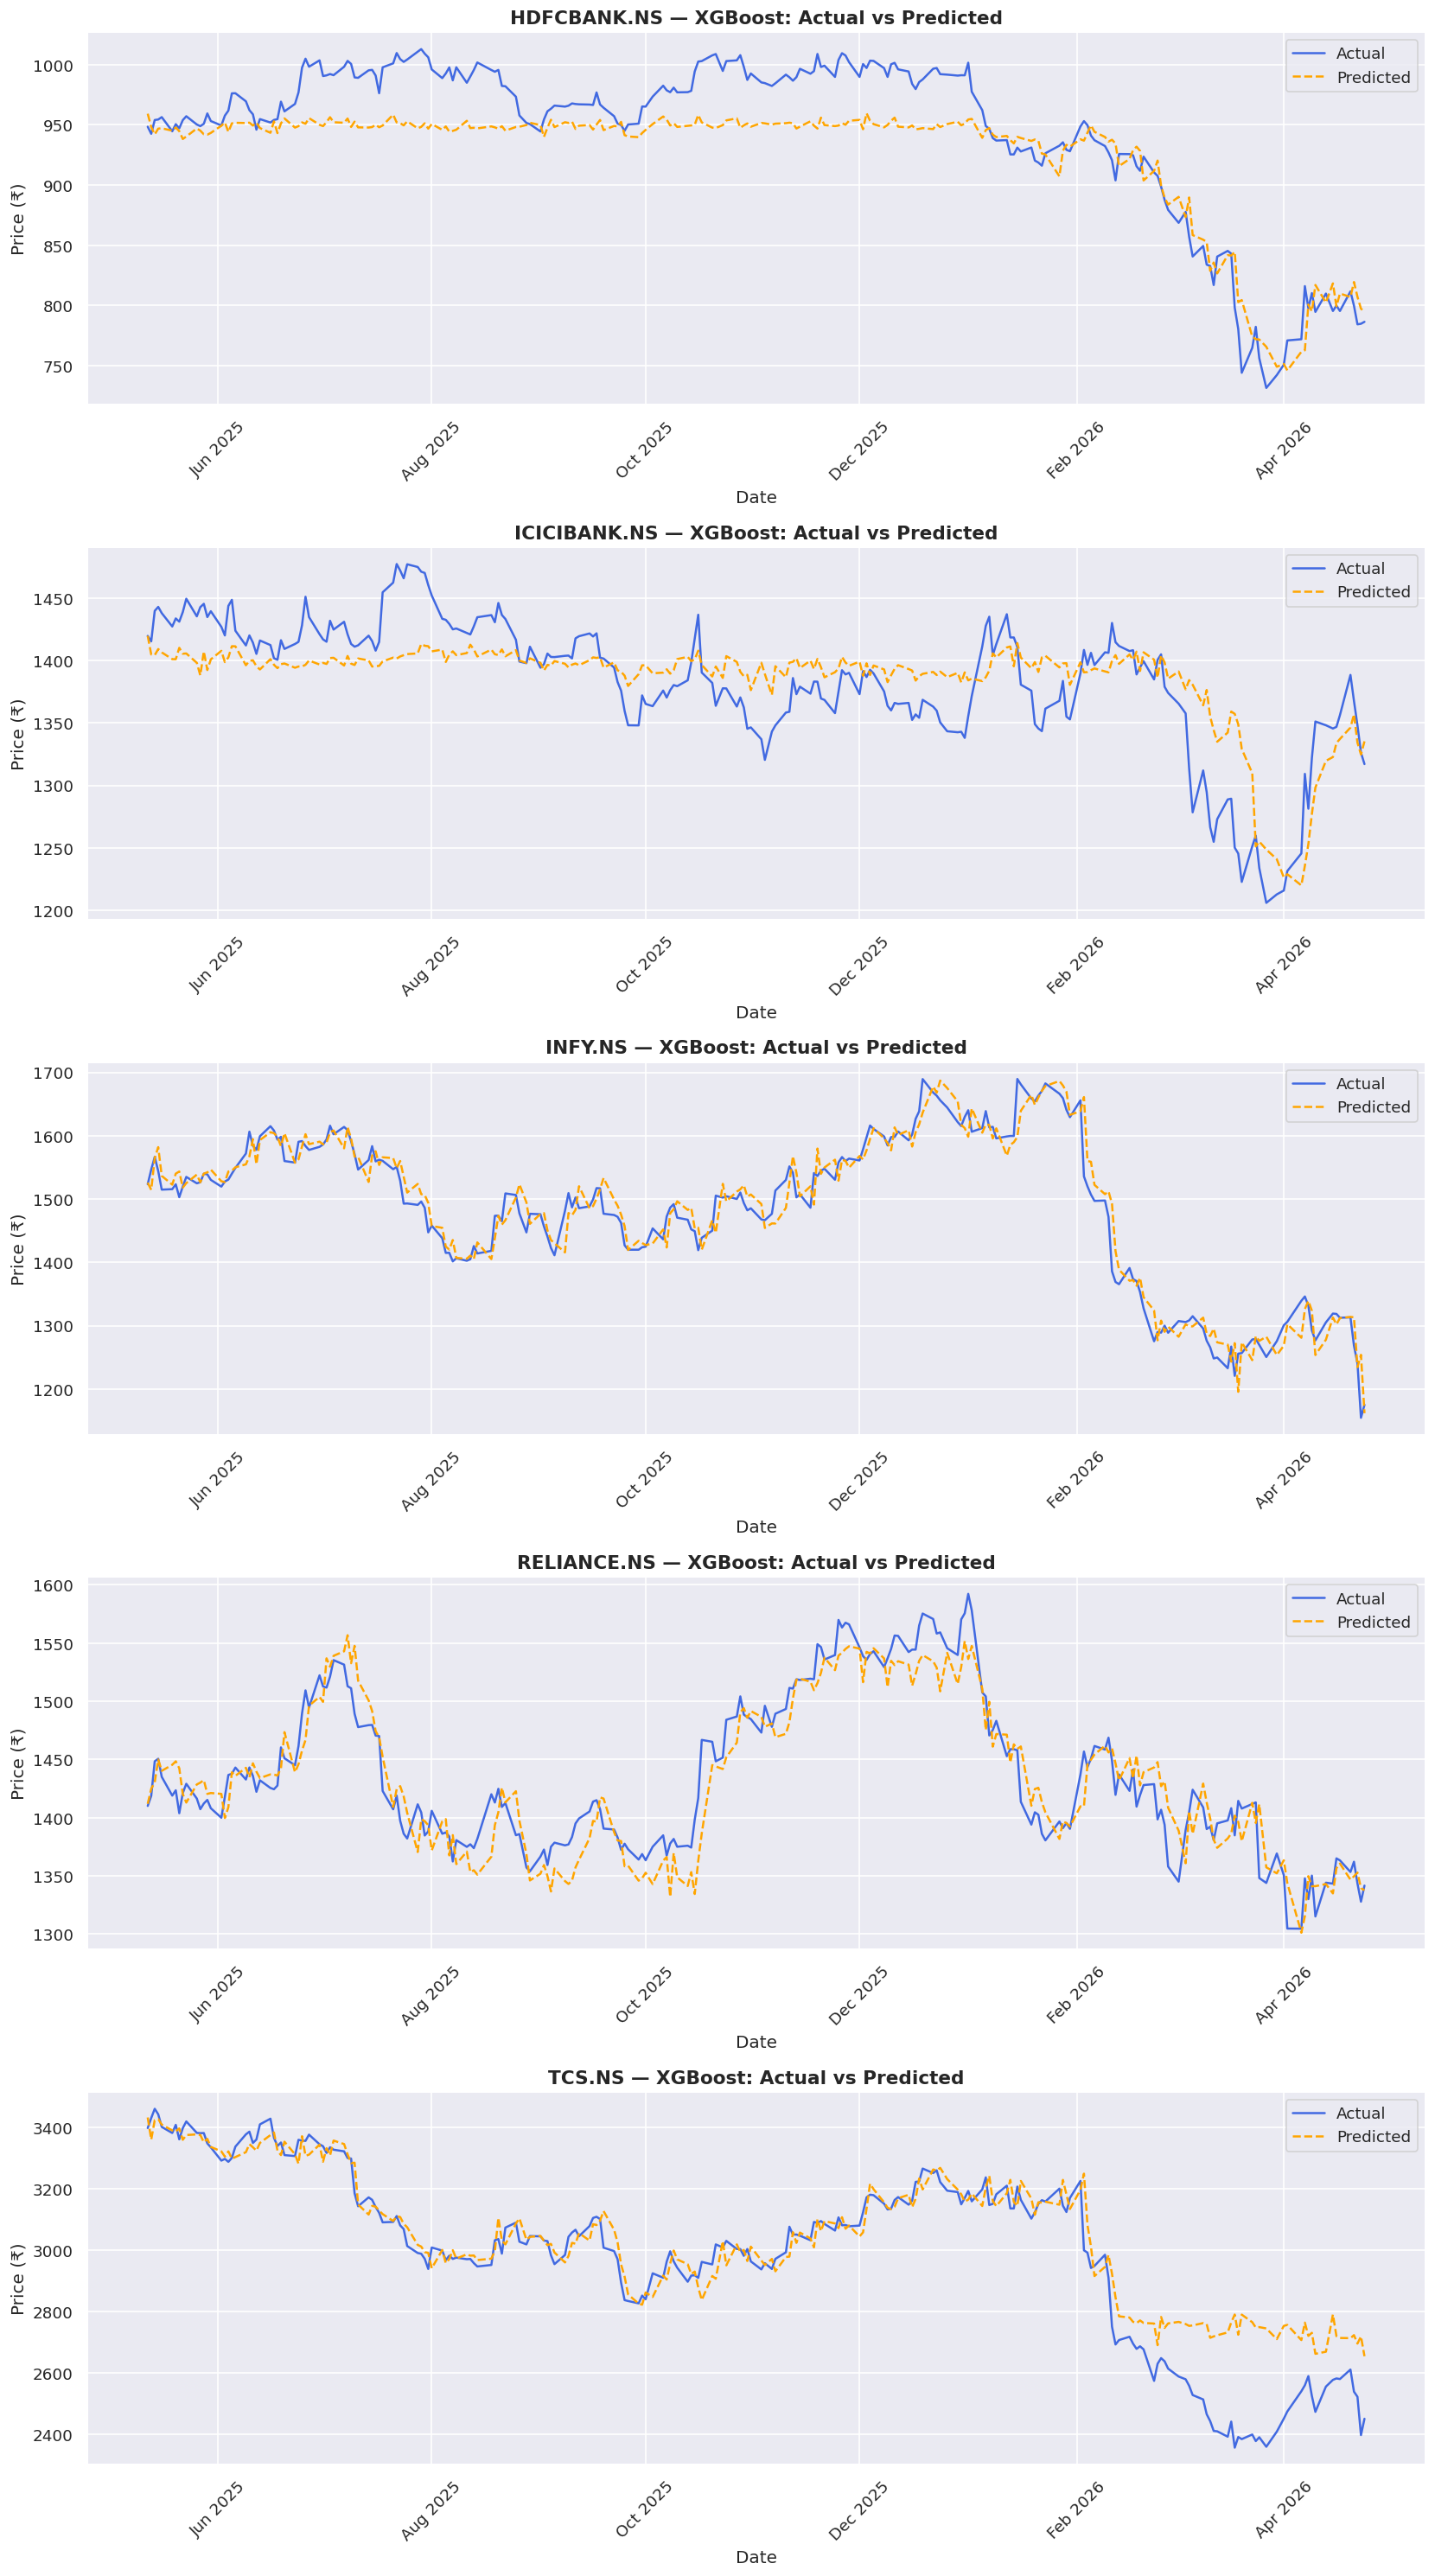

In [88]:
symbols = list(xgb_results.keys())
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

if len(symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols):
    res = xgb_results[symbol]
    ax.plot(res["test_dates"], res["actual"],    label="Actual",    color="royalblue", linewidth=1.5)
    ax.plot(res["test_dates"], res["predicted"], label="Predicted", color="orange",    linewidth=1.5, linestyle="--")
    ax.set_title(f"{symbol} — XGBoost: Actual vs Predicted", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("xgb_predictions.png", bbox_inches="tight")
plt.show()

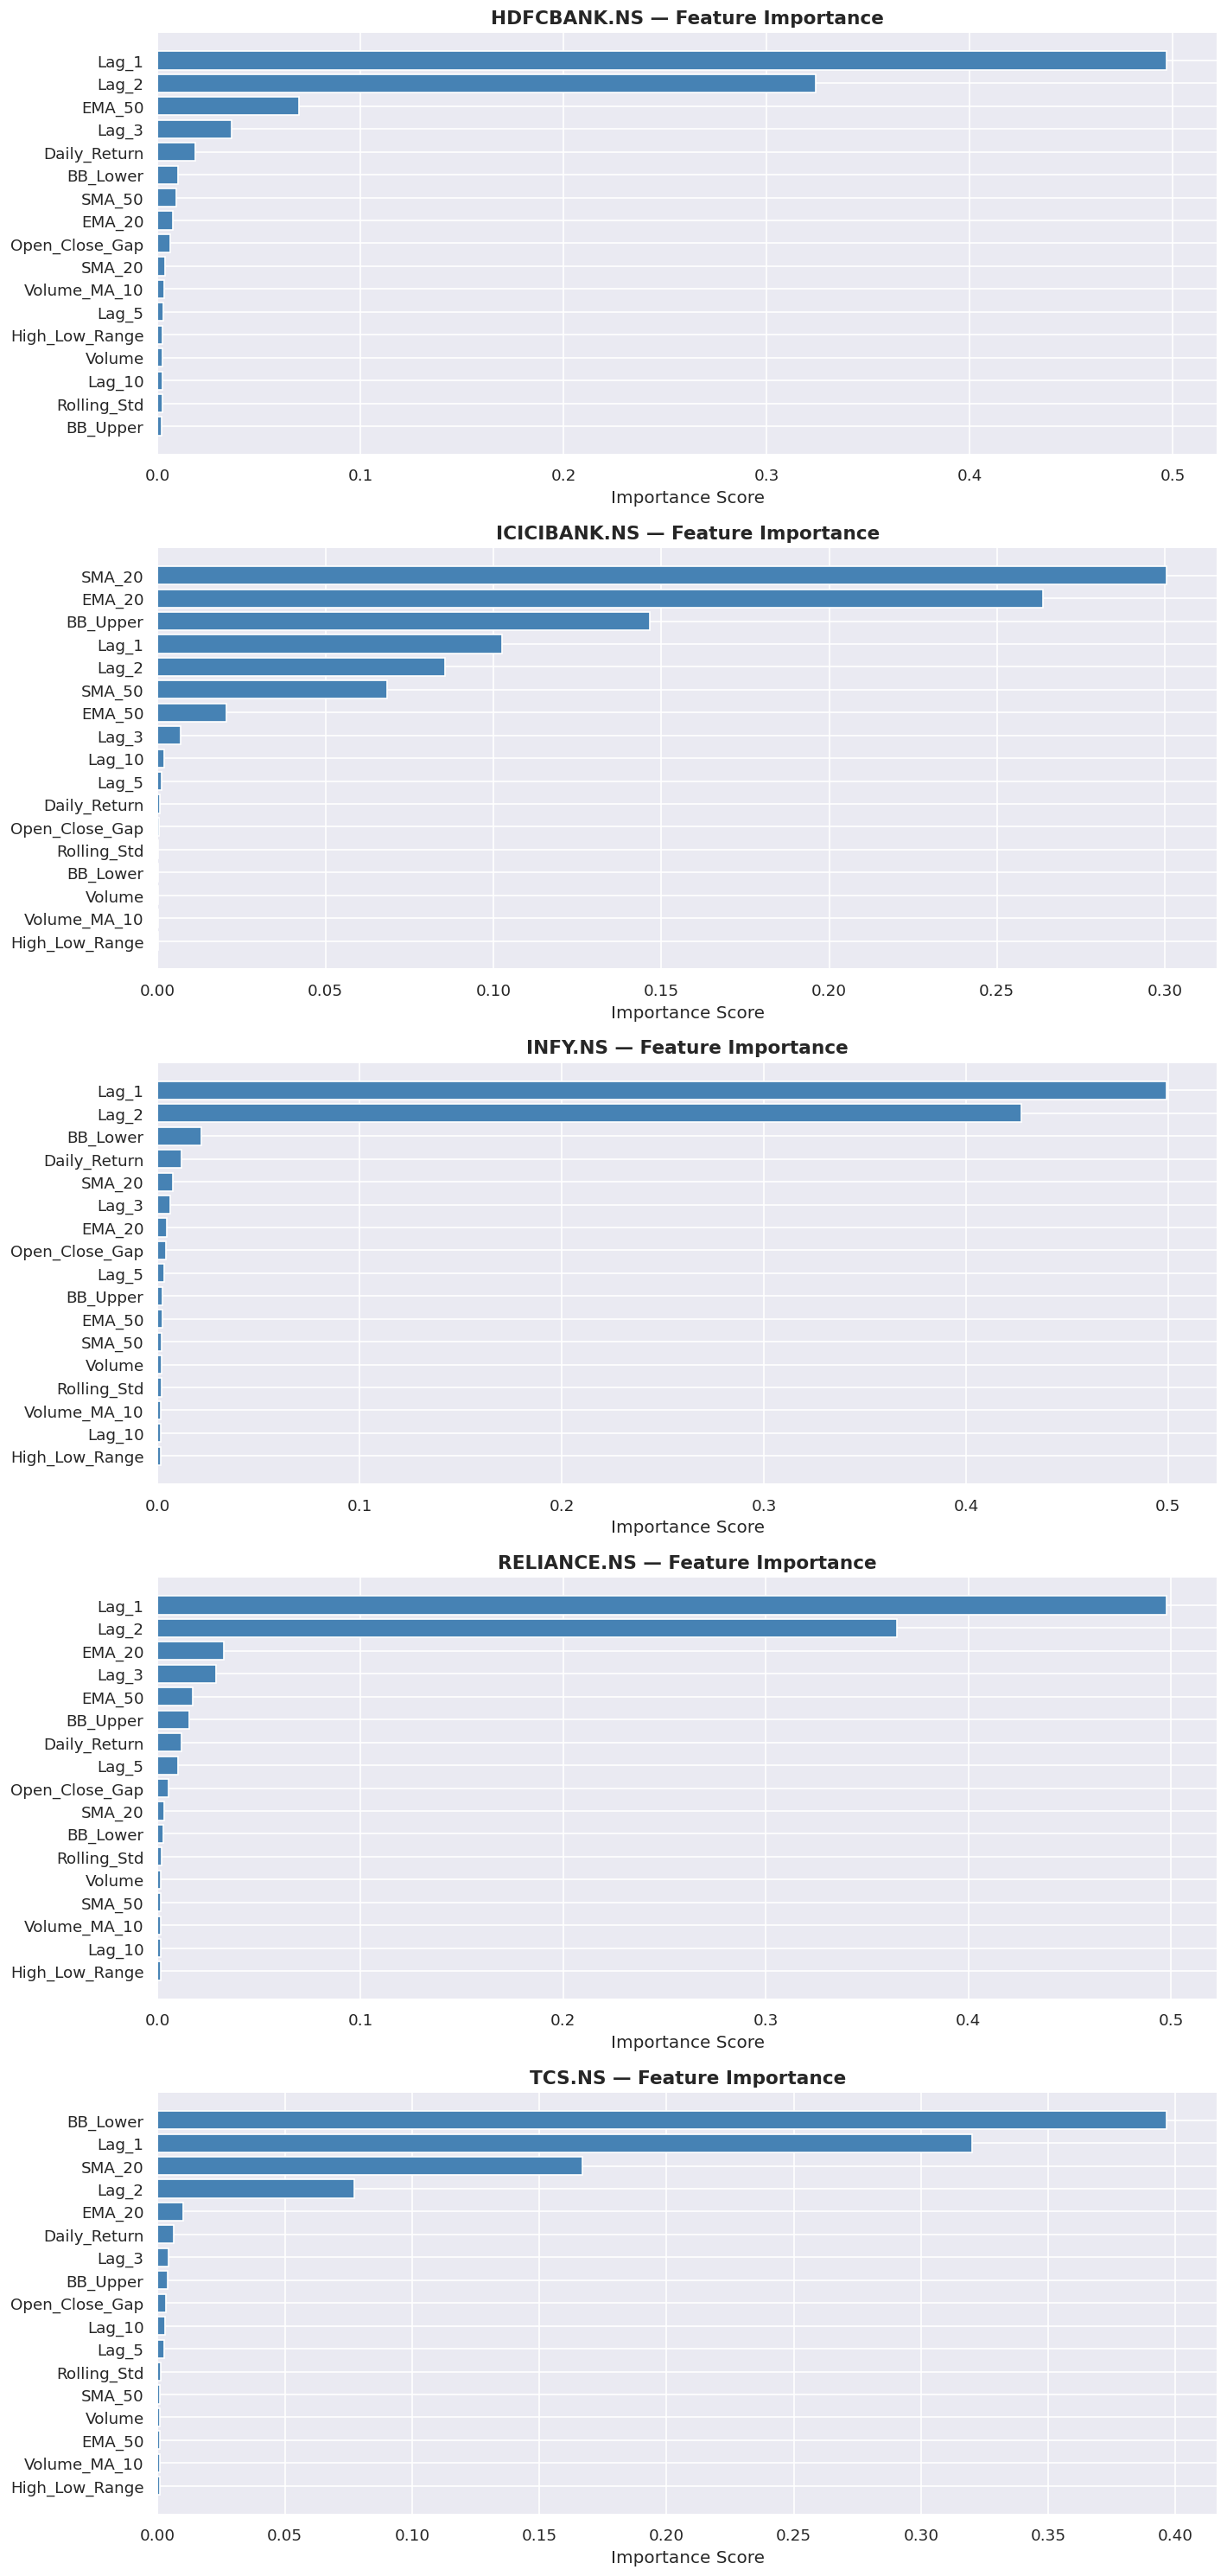

In [89]:
fig, axes = plt.subplots(len(symbols), 1, figsize=(12, 5 * len(symbols)))

if len(symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols):
    model = xgb_results[symbol]["model"]

    importance_df = pd.DataFrame({
        "Feature"    : FEATURES,
        "Importance" : model.feature_importances_
    }).sort_values("Importance", ascending=True)

    ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
    ax.set_title(f"{symbol} — Feature Importance", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("xgb_feature_importance.png", bbox_inches="tight")
plt.show()

In [90]:
print("\n" + "=" * 60)
print("📊 XGBOOST MODEL PERFORMANCE SUMMARY")
print("=" * 60)

summary = []
for symbol, res in xgb_results.items():
    summary.append({
        "Symbol" : symbol,
        "RMSE"   : round(res["rmse"], 2),
        "MAE"    : round(res["mae"],  2),
        "MAPE %" : round(res["mape"], 2)
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv("xgb_metrics.csv", index=False)
print("\n✅ Metrics saved to xgb_metrics.csv")


📊 XGBOOST MODEL PERFORMANCE SUMMARY
      Symbol   RMSE   MAE  MAPE %
 HDFCBANK.NS  32.21 26.41    2.74
ICICIBANK.NS  34.27 27.28    1.99
     INFY.NS  27.47 20.20    1.38
 RELIANCE.NS  23.63 18.82    1.31
      TCS.NS 114.38 70.30    2.62

✅ Metrics saved to xgb_metrics.csv


In [92]:
# Cell 16 — Predict Future Prices

# FUTURE_DAYS = 1  # how many days ahead to predict

future_results = {}

for symbol in df_featured["Symbol"].unique():
    print(f"\n🔮 Predicting next {FUTURE_DAYS} days for {symbol}...")

    data   = df_featured[df_featured["Symbol"] == symbol].copy()
    data   = data.sort_values("Date").reset_index(drop=True)

    model  = xgb_results[symbol]["model"]
    scaler = xgb_results[symbol]["scaler"]

    # Start from the last known row
    last_row = data.iloc[-1].copy()
    future_preds = []
    future_dates = []

    last_date = pd.to_datetime(data["Date"].iloc[-1])

    # for i in range(FUTURE_DAYS):
    # Build feature row from last known values
    feature_row = pd.DataFrame([{
        "Lag_1"          : last_row["Close"],
        "Lag_2"          : last_row["Lag_1"],
        "Lag_3"          : last_row["Lag_2"],
        "Lag_5"          : last_row["Lag_3"],
        "Lag_10"         : last_row["Lag_5"],
        "SMA_20"         : last_row["SMA_20"],
        "SMA_50"         : last_row["SMA_50"],
        "EMA_20"         : last_row["EMA_20"],
        "EMA_50"         : last_row["EMA_50"],
        "BB_Upper"       : last_row["BB_Upper"],
        "BB_Lower"       : last_row["BB_Lower"],
        "Rolling_Std"    : last_row["Rolling_Std"],
        "Daily_Return"   : last_row["Daily_Return"],
        "High_Low_Range" : last_row["High_Low_Range"],
        "Open_Close_Gap" : last_row["Open_Close_Gap"],
        "Volume"         : last_row["Volume"],
        "Volume_MA_10"   : last_row["Volume_MA_10"],
    }])

    scaled      = scaler.transform(feature_row)
    predicted   = model.predict(scaled)[0]

    # Next business day (skip weekends)
    next_date = last_date + pd.offsets.BDay(1)

        # future_preds.append(predicted)
        # future_dates.append(next_date)

        # # Roll forward — predicted price becomes next row's Lag_1
        # last_row["Lag_10"]  = last_row["Lag_5"]
        # last_row["Lag_5"]   = last_row["Lag_3"]
        # last_row["Lag_3"]   = last_row["Lag_2"]
        # last_row["Lag_2"]   = last_row["Lag_1"]
        # last_row["Lag_1"]   = last_row["Close"]
        # last_row["Close"]   = predicted
        # last_date           = next_date

    future_results[symbol] = {
        "date"  : next_date,
        "price" : predicted
    }

    print(f"   ✅ Done — predicted ₹{predicted:.2f}")


🔮 Predicting next 1 days for HDFCBANK.NS...
   ✅ Done — predicted ₹793.60

🔮 Predicting next 1 days for ICICIBANK.NS...
   ✅ Done — predicted ₹1320.58

🔮 Predicting next 1 days for INFY.NS...
   ✅ Done — predicted ₹1086.20

🔮 Predicting next 1 days for RELIANCE.NS...
   ✅ Done — predicted ₹1312.40

🔮 Predicting next 1 days for TCS.NS...
   ✅ Done — predicted ₹2653.88


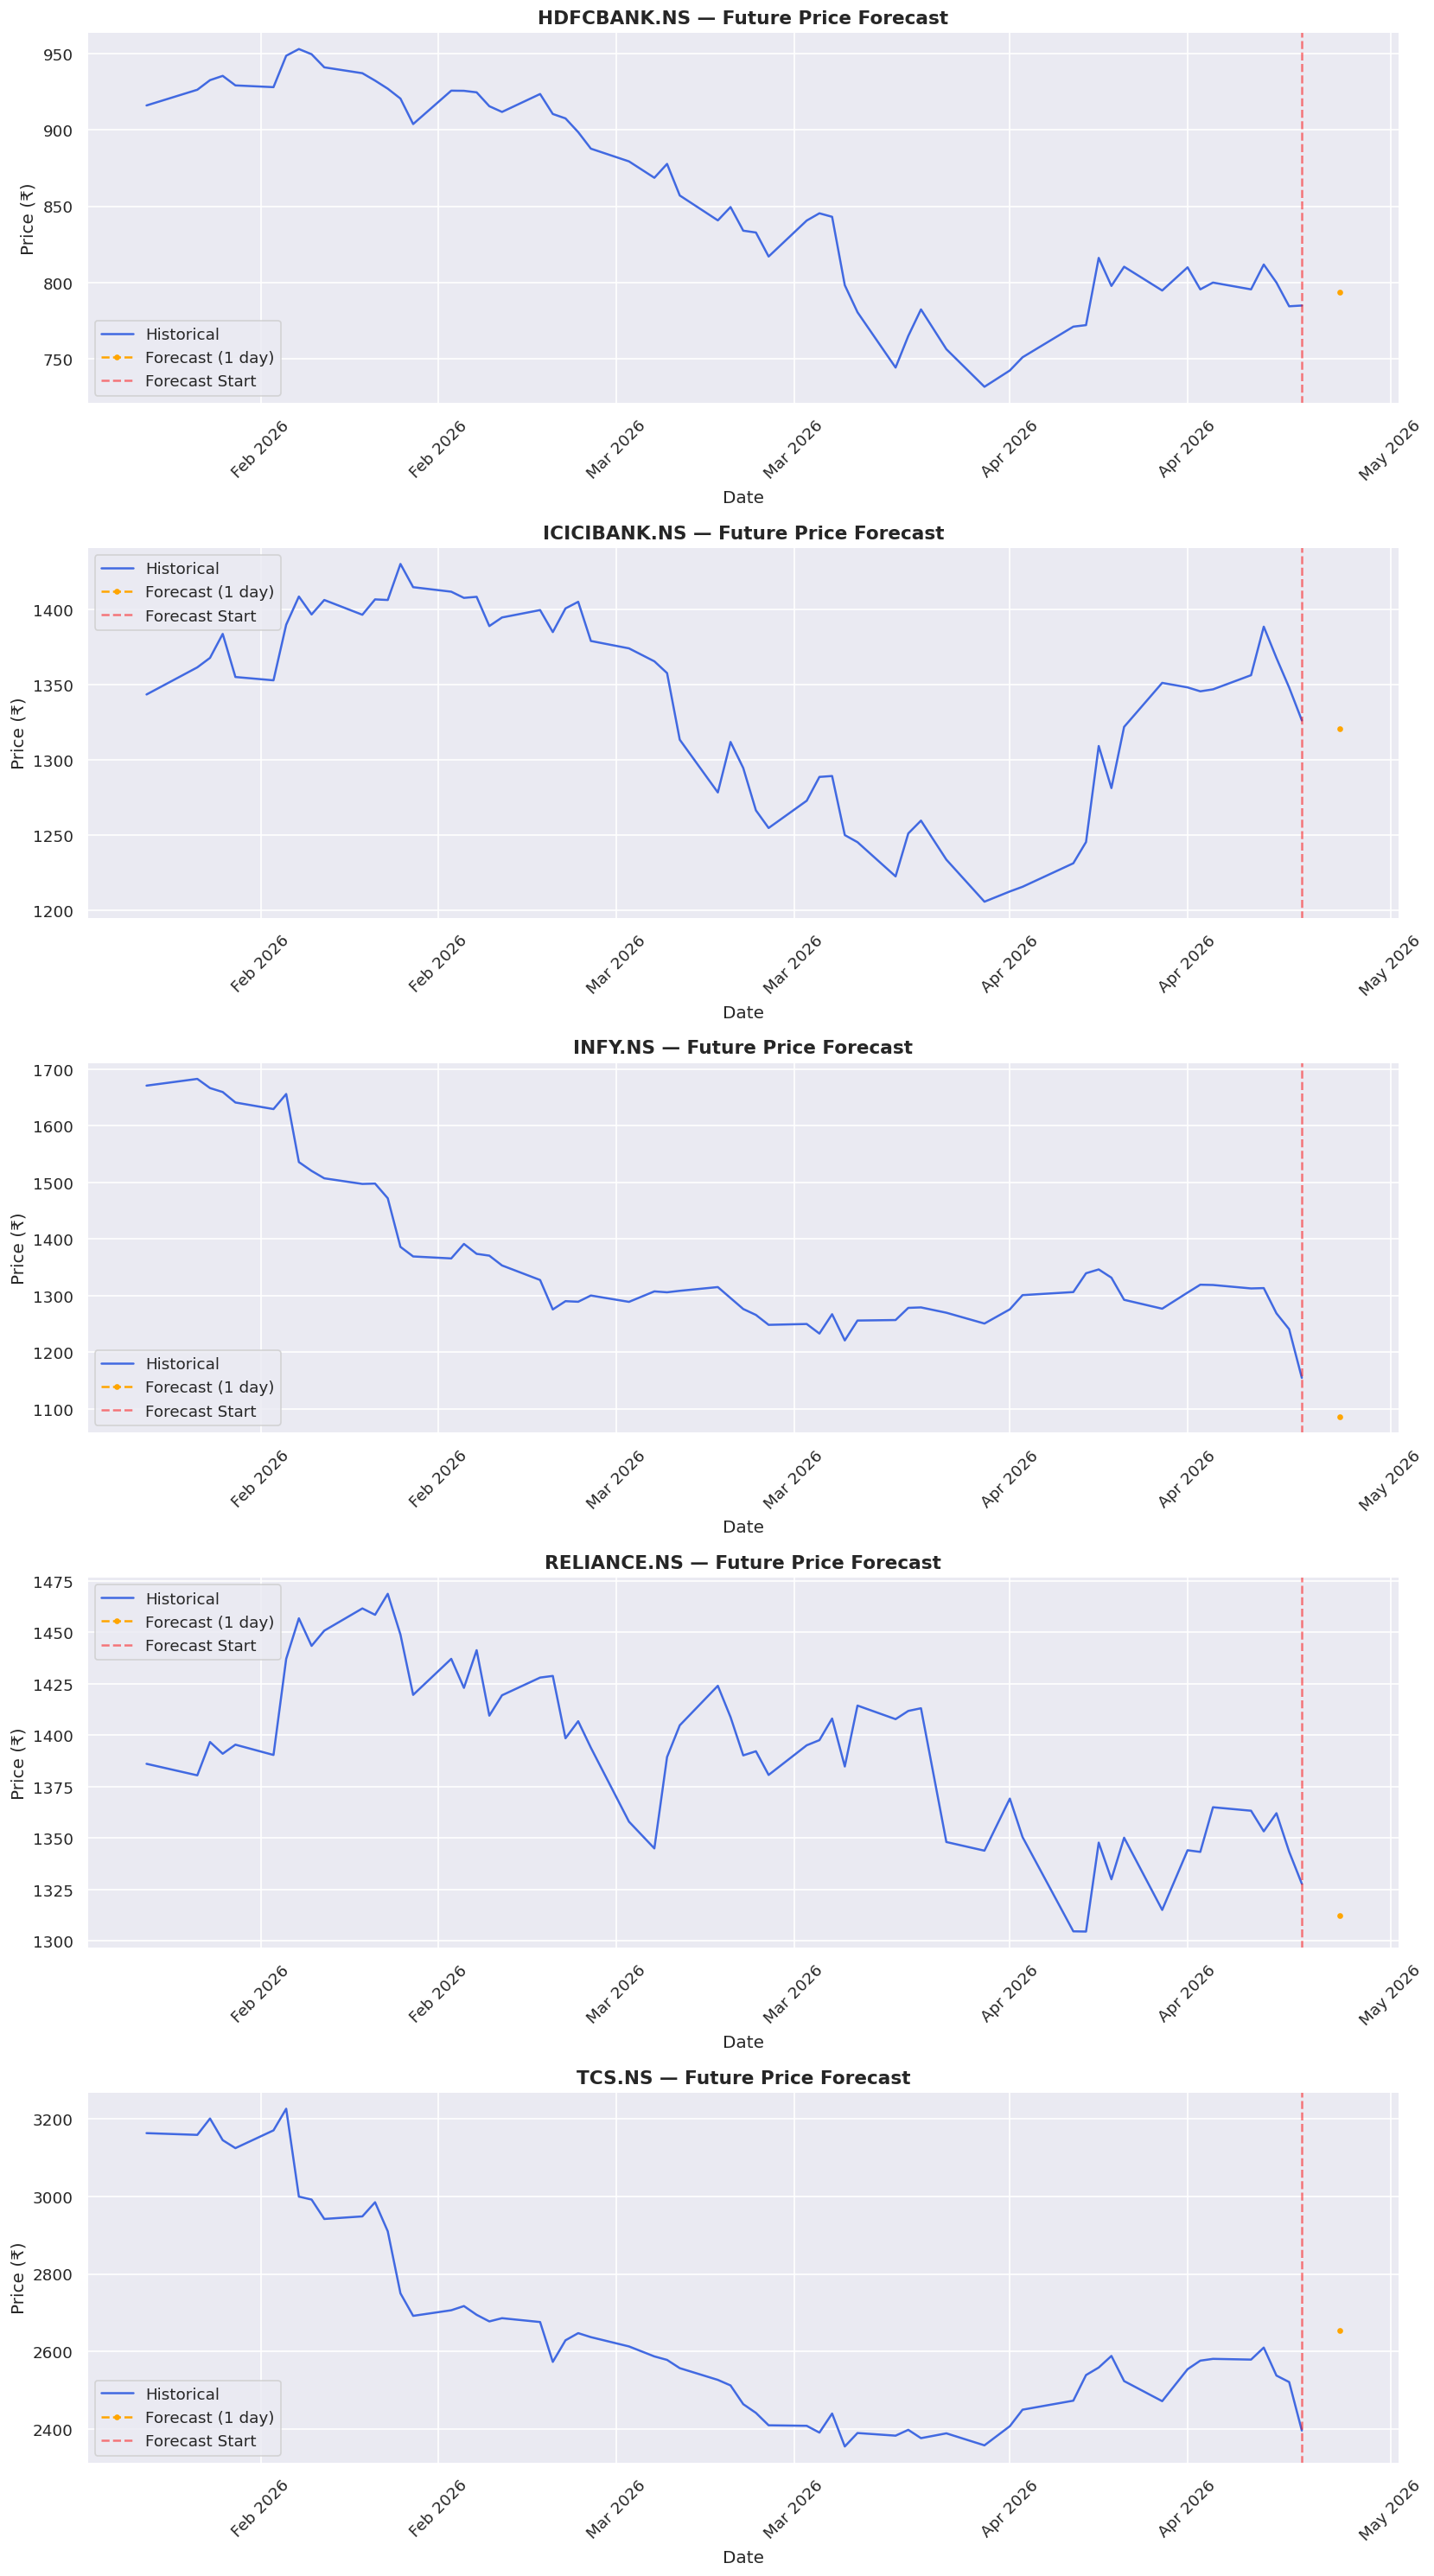

In [93]:
fig, axes = plt.subplots(len(future_results), 1, figsize=(14, 5 * len(future_results)))

if len(future_results) == 1:
    axes = [axes]

for ax, symbol in zip(axes, future_results.keys()):
    # Last 60 days of actual data for context
    actual_data = df_featured[df_featured["Symbol"] == symbol].tail(60)
    fut         = future_results[symbol]

    ax.plot(actual_data["Date"], actual_data["Close"],
            label="Historical", color="royalblue", linewidth=1.5)
    ax.plot([fut["date"]], [fut["price"]],
            label=f"Forecast (1 day)", color="orange",
            linewidth=1.5, linestyle="--", marker="o", markersize=3)

    ax.axvline(x=actual_data["Date"].iloc[-1], color="red",
               linestyle="--", alpha=0.5, label="Forecast Start")

    ax.set_title(f"{symbol} — Future Price Forecast", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("xgb_future_forecast.png", bbox_inches="tight")
plt.show()